# Chapter 25. `gpt2` Continual Pretraining — 대규모 사전학습 모델을 TinyStories 로 계속 학습

**목표**: Phase 4 의 두 번째 챕터. Ch 24 에서 *random init 작은 GPT (약 3M params) 를 TinyStories 로 from scratch 사전학습* 했다면, 이번엔 **OpenAI `gpt2` (124M params, WebText 약 40GB 사전학습된 본체)** 를 *같은 TinyStories 데이터* 로 **continual pretraining** (계속 사전학습 / continual learning) 합니다. **같은 CausalLM task, 같은 LM head, 같은 collator, 같은 loss** — 변하는 건 *모델 로드 한 줄 + 학습률* 뿐. 그게 GPT 시대 *학습 단계 2 (continual pretraining)* 의 본질입니다.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 15-20분 (데이터 로드 약 2분 + gpt2 로드·토큰화 약 2분 + 학습 전 baseline generation 약 1분 + continual pretraining 약 8-10분 + 학습 후 generation + 3-way 비교 약 2분)

---

## 학습 흐름

1. 📊 **누적 추적표** — Ch 22-24 + 본 챕터 강조 + Ch 26 예고
2. 🔄 **변경점 (Diff from Ch 24)** — *모델 출발점 + 토크나이저 + lr* 만 변함. *데이터·trainer·collator·loss 는 동일*
3. 🎯 **GPT 시대 학습 4단계 표** — 본 챕터의 위치 (단계 2). Ch 25 는 *SFT 가 아님* 을 명확히
4. 📐 **Loss** — 변화 없음 (CE next-token). random baseline 차이만 (`ln(2048) ≈ 7.62` → `ln(50257) ≈ 10.82`), 다만 *시작점이 random 이 아닌 사전학습된 본체* 라는 게 핵심
5. 🔤 **토크나이저 노트** — *gpt2 BPE 그대로* (vocab 50,257). Ch 24 의 직접 학습 BPE (vocab 2,048) 와 비교
6. 🚀 **실습**: TinyStories 30K → `gpt2` 로드 → 학습 전 generation → continual pretraining → 학습 후 generation
7. 🆚 **3-way generation 비교** — Ch 24 (scratch) vs Ch 25 BEFORE (gpt2 그대로) vs Ch 25 AFTER (continual pretraining)
8. 📦 **등장 라이브러리** / 🎯 **체크포인트** / ❓ **FAQ** (답변 포함)

---

> 📒 **사전 학습 자료**: Ch 24 (영어 GPT scratch + TinyStories). 본 챕터는 Ch 24 와 *데이터·trainer·collator·loss 모두 같고 본체 출발점·토크나이저·lr 만 다른* 격리 실험. *trainer 코드 차이가 극단적으로 적음* — 그게 *학습 단계 2 (continual pretraining)* 의 본질입니다.

## 📊 누적 추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Loss |
|---|---|---|---|---|---|
| 22 | 작은 BERT (한국어, scratch) | `klue/bert-base` (가져옴) | 한국어 위키 paragraphs | MLM head | `CrossEntropyLoss` (masked 15%) |
| 23 | Ch 22 + 분류 헤드 | (Ch 22 와 동일) | NSMC 이진 | `Linear(H, 2)` | `CrossEntropyLoss` |
| 24 | 작은 GPT2 (직접, scratch, 약 3M) | BPE (직접 학습, vocab 2,048) | TinyStories 30K | `Linear(H, V)` (LM head, weight tied) | `CrossEntropyLoss` (next-token) |
| **25 ← 여기** | **`gpt2` (124M, OpenAI WebText 사전학습)** | **BPE (gpt2 그대로, vocab 50,257)** | **TinyStories 30K (Ch 24 와 동일)** | **`Linear(H, V)` (LM head 그대로)** | **`CrossEntropyLoss` (next-token) — *continual pretraining***  |
| 26 (다음) | 작은 GPT (한국어, scratch) | BPE (한국어 직접 학습) | 한국어 TinyStories-Korean | `Linear(H, V)` (LM head, weight tied) | `CrossEntropyLoss` (next-token) |

전체 챕터 표는 [루트 README](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표) 를 참고하세요.

---

### Ch 24 ↔ Ch 25 격리 실험의 통제 변수

| 항목 | Ch 24 | **Ch 25 (본 챕터)** | 같음 / 다름 |
|---|---|---|---|
| 데이터 | TinyStories 30K | TinyStories 30K | **같음** (통제 변수) |
| Trainer 클래스 | `transformers.Trainer` | `transformers.Trainer` | **같음** |
| Data collator | `DataCollatorForLanguageModeling(mlm=False)` | `DataCollatorForLanguageModeling(mlm=False)` | **같음** |
| Loss | CE next-token (`labels = input_ids.clone()`) | CE next-token (`labels = input_ids.clone()`) | **같음** |
| 본체 출발점 | `GPT2LMHeadModel(config)` random init (3M) | `AutoModelForCausalLM.from_pretrained("gpt2")` (124M) | **다름** |
| 토크나이저 | BPE 직접 학습 (vocab 2,048) | `AutoTokenizer.from_pretrained("gpt2")` (vocab 50,257) | **다름** (본체와 운명공동체) |
| 학습률 | 3e-4 (scratch 표준) | **2e-5** (continual pretraining 표준) | **다름** |
| 학습 step | 약 1,500 | **약 500-800** | **다름** (본체 이미 학습됨) |

> **세 줄 차이가 곧 *학습 단계 2 (continual pretraining)* 의 정의** — 같은 task, 같은 collator, 같은 loss, 같은 trainer. *모델 로드 한 줄 + 토크나이저 한 줄 + lr 한 숫자* 만 바꾸면 됩니다.

## 🔄 변경점 (Diff from Ch 24)

| 축 | Ch 24 (영어 GPT scratch) | Ch 25 (본 챕터, gpt2 continual pretraining) |
|---|---|---|
| **본체** | 작은 GPT2 (약 3M params, random init) | **`gpt2`** (124M, OpenAI WebText 약 40GB 사전학습) ← *출발점 변화* |
| **토크나이저** | BPE 직접 학습 (vocab 2,048) | **`AutoTokenizer.from_pretrained("gpt2")`** (vocab 50,257) ← *본체에 맞춰 함께 변함* |
| 데이터 | TinyStories 30K | **TinyStories 30K (동일)** ← 통제 변수 |
| Trainer | `transformers.Trainer` | **`transformers.Trainer` (동일)** |
| Data collator | `DataCollatorForLanguageModeling(mlm=False)` | **(동일)** |
| Loss | CE next-token (`labels = input_ids.clone()`) | **(동일)** |
| **학습률** | 3e-4 | **2e-5** ← *유일한 hyperparam 큰 차이* |
| 학습 step | 약 1,500 (T4 약 18분) | **약 500-800 (T4 약 8-10분)** — 본체 이미 학습됨 |
| Generation 품질 | grammatical 한 동화 풍 | **자연스러운 동화 + 일반 도메인 폭** ← 메시지 |

> **핵심**: *Ch 24 ↔ Ch 25 는 데이터·trainer·collator·loss 모두 같고 본체 출발점·토크나이저·lr 만 다름*. **trainer 코드 차이가 극단적으로 적음** — 그게 GPT 시대 학습 단계 2 (continual pretraining) 의 본질. *task adaptation 의미의 fine-tune 이 아닙니다* — head 바뀌지 않고, task (next-token 예측) 바뀌지 않습니다. 데이터만 바뀝니다.

## 🎯 GPT 시대 학습 4단계 — 본 챕터의 위치 (단계 2)

Ch 24 에서 도입한 GPT 시대 학습 4단계 표의 *단계 2 (continual pretraining)* 가 본 챕터입니다.

| 단계 | 정확 용어 | 의미 | `labels = -100` 자리 | 본 커리큘럼 | 본 챕터? |
|---|---|---|---|---|---|
| 1 | **Pretraining** (사전학습) | 일반 코퍼스 위에 random init 본체부터 학습 | pad 만 | Ch 24, Ch 26 | |
| 2 | **Continual pretraining** (계속 사전학습 / continual learning) | *사전학습된 본체* 를 *새 데이터* 로 *같은 CausalLM task* 더 학습. **head 그대로, task 그대로, 데이터만 새로** | pad 만 (단계 1 과 동일) | **Ch 25 ← 여기** | ✅ |
| 3 | **SFT** (Supervised Fine-Tuning / Instruction tuning) | instruction-response 쌍으로 *행동 정렬*. `labels[:prompt_len] = -100` 으로 답변 부분만 학습 | **prompt 부분** | Ch 28 | |
| 4 | **Alignment** (DPO / RLHF / GRPO) | preference 또는 verifier reward 로 *선호 정렬* | (RL 내부) | Ch 30-31 | |

### ⚠️ Ch 25 는 *SFT 가 아닙니다*

본 챕터를 *fine-tune* 으로 부르면 *단계 2 / 3 / 4* 가 모두 섞여 혼동이 생깁니다. Ch 25 의 정확한 위치는:

- **`task adaptation` 의미의 fine-tune 이 아님** — output head 안 바뀜 (LM head 그대로), task 안 바뀜 (next-token 예측 그대로), loss 안 바뀜 (CE)
- **`instruction tuning` 의미의 SFT 가 아님** — `labels = -100` 자리가 *pad 만* (Ch 24 와 동일). prompt-response 쌍 데이터 형식이 아니라 *연속된 일반 텍스트*
- **`continual pretraining` 그 자체** — *사전학습된 본체 + 새 도메인 데이터 + 같은 CausalLM task* 의 조합. *데이터만 바뀐 단계 1 의 연장*

> SFT (단계 3) 는 Ch 28 에서 본격. *왜 모델이 instruction 을 따라가게 되는가* 는 `labels[:prompt_len] = -100` 한 줄로 정확히 설명됩니다. 본 챕터의 collator 출력 (거의 모든 자리 = 학습 신호) 이 그 한 줄과 정확히 대비되는 *학습 단계 2 의 기준선*.

## 📐 Loss — 변화 없음, 다만 *시작점* 이 다름

Ch 24 와 *완전히 동일* 한 `CrossEntropyLoss` (next-token, `mlm=False`). `labels = input_ids.clone()`, pad 만 `-100`. 단 *vocab 차원이 2,048 → 50,257 로 커진* 영향과, *모델 본체가 random init 이 아닌 이미 학습된 상태* 라는 두 차이가 *loss 곡선의 시작 지점* 을 결정합니다.

### Random baseline 의 변화

| 토크나이저 | vocab 차원 | `ln(vocab)` (uniform CE) | 챕터 |
|---|---|---|---|
| 직접 학습 BPE | 2,048 | 7.62 | Ch 24 |
| **gpt2 BPE** | **50,257** | **10.82** | **Ch 25** |
| `klue/bert-base` WordPiece | 32,000 | 10.37 | Ch 22-23 (참고) |

*만약* gpt2 본체가 random init 이었다면 첫 step loss 가 약 10.82 부근에서 시작할 것입니다. 하지만 **gpt2 본체는 이미 WebText 약 40GB 로 사전학습되어 있어** *TinyStories 평가에서도 시작 loss 가 random baseline 보다 훨씬 낮습니다* — 그게 학습 단계 2 의 핵심 차이.

### 숫자로 감 잡기 — *시작점 ↔ 도달점*

| 상태 | 정답 토큰 확률 | $-\log p$ |
|---|---|---|
| 균등 추측 (gpt2 vocab 50,257) | $1/50257$ | **10.82** ← random baseline (도달 불필요) |
| gpt2 사전학습 그대로, TinyStories 평가 | $0.05$ - $0.10$ 범위 | **2.5 - 3.0** ← *우리 시작점* (이미 좋음) |
| Continual pretraining 후 (수백 step) | $0.10$ - $0.20$ 범위 | **1.6 - 2.3** ← *우리 도달점* |
| Reference: 학습 길게 했을 때 | $0.25$+ | 약 1.4 |

> Ch 24 의 시작 loss `약 7.6` (random baseline) 와 Ch 25 의 시작 loss `약 2.5-3.0` (사전학습된 본체의 평가 loss) 의 차이가 *대규모 사전학습이 본체에 미리 새겨둔 next-token 분포* 의 정량적 가치. *Ch 25 는 random 에서 시작하지 않습니다*.

### Perplexity 환산

$\text{PPL} = e^{L}$:

| CLM loss | PPL | 해석 |
|---|---|---|
| 10.82 | 50,257 | 균등 추측 (50K vocab 전체) |
| 3.0 | 20 | 약 20 개 후보 ← Ch 25 시작 영역 |
| 2.0 | 7.4 | 약 7 개 후보 ← Ch 25 도달 영역 |
| 1.4 | 4.1 | 거의 결정적 |

> *vocab 50K 의 거대한 공간에서 평균 7-20 개 후보로 좁힌* 상태에서 시작해 더 좁힙니다. Ch 24 의 vocab 2K 와 정량적 비교는 어렵지만 (vocab 단위가 다름), *generation 품질* 로는 직접 비교 가능 — 그게 본 챕터 §7 (3-way 비교) 의 역할.

## 🔤 토크나이저 노트 — `gpt2` BPE 그대로 (vocab 50,257)

본 챕터에서는 토크나이저를 *학습하지 않습니다*. `AutoTokenizer.from_pretrained("gpt2")` 한 줄로 OpenAI 가 WebText 위에 학습해 둔 byte-level BPE 를 그대로 가져옵니다.

### 왜 직접 학습하지 않는가 — *토크나이저는 본체와 운명공동체*

`gpt2` 본체의 input embedding `wte` (50257 × 768) 와 LM head (768 × 50257) 는 *gpt2 가 학습한 그 vocab id 체계* 에 맞춰 학습되어 있습니다. 만약 *다른 vocab* (예: Ch 24 의 직접 학습 BPE 2,048) 을 붙이면:

- token id `100` 이 *gpt2 가 학습한 토큰* 과 *완전히 다른 byte 조각* 을 가리킴
- `wte[100]` 의 vector 는 *gpt2 가 학습한 token 100* 의 의미인데, *우리가 붙인 token 100* 은 무관한 byte
- 결과: 본체 weight 가 *유효한 신호가 아님*. 사실상 random init 과 같은 상태에서 시작

따라서 **사전학습 모델을 가져올 때는 그 모델이 학습한 토크나이저를 *반드시 함께* 가져와야** 합니다. Ch 19 에서 다룬 *토크나이저는 모델과 운명공동체* 원칙의 정확한 적용 사례.

### Ch 24 ↔ Ch 25 토크나이저 비교

| 항목 | Ch 24 | **Ch 25 (본 챕터)** |
|---|---|---|
| 알고리즘 | byte-level BPE | byte-level BPE (같은 종류) |
| Vocab 크기 | 2,048 | **50,257** (약 25배) |
| 학습 코퍼스 | TinyStories 30K (약 4-6M 토큰) | **WebText 약 40GB** (OpenAI 가 학습) |
| 학습 주체 | 본 챕터에서 직접 학습 | **OpenAI 가 미리 학습** (그대로 사용) |
| 특수 토큰 | `<\|endoftext\|>` (bos = eos = pad) | `<\|endoftext\|>` (bos = eos, pad 는 별도 지정 필요) |

### `gpt2` 의 pad token 컨벤션

gpt2 는 *원래 pad token 이 없습니다* — 그래서 batch 학습 시 한 줄을 추가합니다:

```python
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # gpt2 의 pad 컨벤션
```

EOS 토큰을 pad 로 재활용. `group_texts` 패턴에서 chunk 길이가 모두 같으면 pad 가 거의 없어 실용적으로는 영향 없음.

> Ch 26 (한국어 GPT scratch) 에서는 다시 *직접 학습* 으로 돌아갑니다 — 한국어는 gpt2 BPE 로 표현하면 *byte 단위로 잘게 쪼개져 UNK 폭증* 이라 한국어 코퍼스 위에 새 토크나이저를 학습해야 합니다. 그게 Ch 26 가 *scratch* 인 이유.

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers tokenizers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/48.9 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 128.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 128.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 128.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.7 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# device 자동 감지 - Colab T4 / 로컬 MPS / CPU 모두 지원
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    vram_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"device     : cuda  ({device_name})")
    print(f"VRAM total : {vram_gib:.2f} GiB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("device     : mps  (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("device     : cpu  (training will be very slow - Colab T4 recommended)")

print(f"torch      : {torch.__version__}")

# 재현성
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# fp16 은 CUDA 에서만 (MPS 는 미지원, CPU 는 의미 없음)
USE_FP16 = (device.type == "cuda")
print(f"use fp16   : {USE_FP16}")

device     : cuda  (Tesla T4)
VRAM total : 14.56 GiB
torch      : 2.11.0+cu128
use fp16   : True


## 1. TinyStories 데이터 로드 — *Ch 24 와 완전히 동일*

본 챕터의 데이터는 *통제 변수*. Ch 24 와 정확히 같은 split 을 사용합니다 (`roneneldan/TinyStories`, train 30K + eval 500). *데이터를 고정하고 본체·토크나이저·lr 만 바꿔 격차를 본다* 가 본 챕터의 격리 실험 설계.

In [3]:
from datasets import load_dataset

N_TRAIN = 30_000      # Ch 24 와 동일
N_VAL   = 500

raw_train = load_dataset("roneneldan/TinyStories", split=f"train[:{N_TRAIN}]")
raw_val   = load_dataset("roneneldan/TinyStories", split=f"validation[:{N_VAL}]")
print("train:", raw_train)
print("val  :", raw_val)
print("\n=== sample story (same as Ch 24) ===")
print(raw_train[0]["text"][:400])

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

train: Dataset({
    features: ['text'],
    num_rows: 30000
})
val  : Dataset({
    features: ['text'],
    num_rows: 500
})

=== sample story (same as Ch 24) ===
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

To


## 2. `gpt2` 토크나이저·모델 로드 — *모델 로드 한 줄로 학습 단계 2 진입*

본 챕터의 *유일한 큰 변화*. Ch 24 의 `GPT2LMHeadModel(config)` random init 대신 `AutoModelForCausalLM.from_pretrained("gpt2")` 한 줄. 토크나이저도 같이 가져옵니다.

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token   # gpt2 의 pad 컨벤션 (EOS 재활용)

model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
print(f"load done: {time.time()-t0:.1f}s")

n_params = model.num_parameters()
print(f"\n=== model ===")
print(f"#params           : {n_params/1e6:.2f} M  (Ch 24 was approx. 3M; Ch 25 is approx. {n_params/3e6:.0f}x larger)")
print(f"vocab_size        : {tokenizer.vocab_size:,}  (Ch 24 was 2,048; Ch 25 is approx. {tokenizer.vocab_size/2048:.0f}x larger)")
print(f"weight tying      : {model.config.tie_word_embeddings}  (lm_head <-> wte shared)")
print(f"fp32 weight size  : {n_params * 4 / 1024**2:.1f} MiB")
print(f"\ntokenizer    : {type(tokenizer).__name__}")
print(f"  eos_token  : {tokenizer.eos_token}  id={tokenizer.eos_token_id}")
print(f"  pad_token  : {tokenizer.pad_token}  id={tokenizer.pad_token_id}  (= eos_token)")
print(f"\nmodel: {type(model).__name__}")
print(f"  - body : {type(model.transformer).__name__}  (Decoder, causal attention)")
print(f"  - head : {type(model.lm_head).__name__}(in={model.lm_head.in_features}, out={model.lm_head.out_features})")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

load done: 9.4s

=== model ===
#params           : 124.44 M  (Ch 24 was approx. 3M; Ch 25 is approx. 41x larger)
vocab_size        : 50,257  (Ch 24 was 2,048; Ch 25 is approx. 25x larger)
weight tying      : True  (lm_head <-> wte shared)
fp32 weight size  : 474.7 MiB

tokenizer    : GPT2Tokenizer
  eos_token  : <|endoftext|>  id=50256
  pad_token  : <|endoftext|>  id=50256  (= eos_token)

model: GPT2LMHeadModel
  - body : GPT2Model  (Decoder, causal attention)
  - head : Linear(in=768, out=50257)


### Ch 24 ↔ Ch 25 코드 diff — *모델·토크나이저 로드 두 줄 차이*

```python
# Ch 24 (영어 GPT scratch) - BPE 직접 학습 후 random init 모델
# bpe = Tokenizer(BPE(unk_token=None))
# trainer = BpeTrainer(vocab_size=2048, ...)
# bpe.train_from_iterator(text_iter, trainer)
# tokenizer = PreTrainedTokenizerFast(tokenizer_object=bpe, bos_token=EOS, eos_token=EOS, pad_token=EOS)
# config = GPT2Config(vocab_size=2048, n_layer=4, n_head=4, n_embd=256, ...)
# model = GPT2LMHeadModel(config)

# Ch 25 (continual pretraining) - 단 두 줄로
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("gpt2")
```

> *trainer·collator·loss 는 같음* — *모델 로드 한 줄 + 토크나이저 한 줄* 로 학습 단계 2 (continual pretraining) 에 진입합니다. 그게 본 챕터의 메시지.

## 3. 토큰화 + `group_texts` — *Ch 24 와 완전히 같은 패턴*

HF causal LM 학습 표준 패턴 (`run_clm.py`) 그대로. Ch 24 와 정확히 같습니다 — *데이터·전처리·collator 는 통제 변수*.

다만 `BLOCK_SIZE` 는 Ch 24 와 동일하게 유지 (128) — *gpt2 본체의 `n_positions=1024` 까지 가능하지만, T4 + 30분 룰 안에서 비교 가능성 우선*.

In [5]:
BLOCK_SIZE = 128   # Ch 24 와 동일

def tokenize_fn(batch):
    return tokenizer(batch["text"])

tok_train = raw_train.map(tokenize_fn, batched=True, remove_columns=["text"], desc="tokenize train")
tok_val   = raw_val.map(tokenize_fn,   batched=True, remove_columns=["text"], desc="tokenize val")

# 각 story 끝에 EOS 부착 (story 경계 표시)
def add_eos(batch):
    new_ids, new_mask = [], []
    for ids in batch["input_ids"]:
        ids = ids + [tokenizer.eos_token_id]
        new_ids.append(ids)
        new_mask.append([1] * len(ids))
    return {"input_ids": new_ids, "attention_mask": new_mask}

tok_train = tok_train.map(add_eos, batched=True, desc="add eos train")
tok_val   = tok_val.map(add_eos,   batched=True, desc="add eos val")

def group_texts(batch):
    concatenated = {k: sum(batch[k], []) for k in batch.keys()}
    total_len = len(concatenated["input_ids"])
    total_len = (total_len // BLOCK_SIZE) * BLOCK_SIZE
    return {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_len, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }

lm_train = tok_train.map(group_texts, batched=True, desc="group train")
lm_val   = tok_val.map(group_texts,   batched=True, desc="group val")

print(f"\ntrain chunks: {len(lm_train):,}  (block_size={BLOCK_SIZE})")
print(f"val   chunks: {len(lm_val):,}")
print(f"approx. train tokens: {len(lm_train) * BLOCK_SIZE / 1e6:.2f} M")
print("\nfirst chunk decode (first 200 chars):")
print(tokenizer.decode(lm_train[0]["input_ids"])[:200])

tokenize train:   0%|          | 0/30000 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 1024). Running this sequence through the model will result in indexing errors


tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

add eos train:   0%|          | 0/30000 [00:00<?, ? examples/s]

add eos val:   0%|          | 0/500 [00:00<?, ? examples/s]

group train:   0%|          | 0/30000 [00:00<?, ? examples/s]

group val:   0%|          | 0/500 [00:00<?, ? examples/s]


train chunks: 51,863  (block_size=128)
val   chunks: 788
approx. train tokens: 6.64 M

first chunk decode (first 200 chars):
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on


**비교 관전 포인트** — 같은 30K stories 가 *gpt2 BPE (vocab 50,257)* 로 토큰화되면 Ch 24 의 *직접 학습 BPE (vocab 2,048)* 보다 *토큰 수가 적습니다* — vocab 이 클수록 한 토큰이 더 긴 byte 시퀀스를 표현하므로. 같은 데이터의 토큰 수 차이가 *토크나이저 vocab 크기의 직접적 효과*.

## 4. 학습 *전* generation — *이미 잘 만들어진 본체* 라는 사실 확인

Ch 24 의 *random init baseline* 은 *영어와 거리 먼 byte 조각* 이었습니다. Ch 25 의 학습 전 baseline 은 *gpt2 가 WebText 로 이미 사전학습된 본체* 라 *학습 시작 시점에 이미 자연스러운 영어 generation* 이 가능합니다.

같은 prompt 3개로 *gpt2 학습 직전 (BEFORE)* generation 을 기록 — 학습 후 (§6) 와 나란히 비교해 *continual pretraining 이 본체에 어떤 변화를 주는가* 를 직접 봅니다.

In [6]:
PROMPTS = [
    "Once upon a time,",
    "The little girl",
    "A big dog",
]
GEN_KWARGS = dict(max_new_tokens=60, do_sample=True, temperature=0.8, top_k=50)


@torch.no_grad()
def generate_text(active_model, prompt: str, gen_tokenizer=None, **kwargs):
    tok = gen_tokenizer if gen_tokenizer is not None else tokenizer
    enc = tok(prompt, return_tensors="pt").to(active_model.device)
    out = active_model.generate(
        **enc,
        pad_token_id=tok.pad_token_id,
        eos_token_id=tok.eos_token_id,
        **kwargs,
    )
    return tok.decode(out[0], skip_special_tokens=True)


torch.manual_seed(SEED)
model.eval()
before_outputs = []
print("=" * 70)
print("BEFORE continual pretraining - gpt2 pretrained on WebText, as-is")
print("=" * 70)
for p in PROMPTS:
    text = generate_text(model, p, **GEN_KWARGS)
    before_outputs.append(text)
    print(f"\n[prompt] {p}")
    print(text)

BEFORE continual pretraining - gpt2 pretrained on WebText, as-is



[prompt] Once upon a time,
Once upon a time, if you don't know what your country's government is doing, you can find out.

In the last few months, I've traveled to dozens of countries around the world, and I've seen the results of that.

My new book — the Making of a Better World Order:



[prompt] The little girl
The little girl has been at her desk all day...for two hours. She's got a pen and paper and a pen and paper, not a pen and paper and pencil. And she is in the middle of writing on that pen and paper. And she is sitting on top of the other girl. And she



[prompt] A big dog
A big dog is a dog that loves to eat, but is also a dog that's afraid to do anything that might hurt others.

In the long run, we find that people who have an allergy to animals are less likely to have allergies to dogs.

But these people are less likely to have


**해석 가이드 — *Ch 24 random init* vs *Ch 25 gpt2 사전학습* 의 직전 비교**

- **Ch 24 학습 직전 (random init)**: *영어와 거리 먼 byte 조각 / 의미 없는 짧은 단어 반복*
- **Ch 25 학습 직전 (gpt2 사전학습 그대로)**: *이미 자연스러운 영어 문장* — *주어 + 동사 + 목적어* 구조, 다양한 도메인 어휘. 다만 *TinyStories 풍은 아님* — WebText 풍 일반 문장 / 뉴스 / 대화 등 (학습 데이터 분포 반영)

> 이 차이가 *학습 시작점의 차이*. Ch 25 는 *random 에서 시작하지 않습니다* — *이미 잘 만들어진 본체* 에서 시작해 *TinyStories 풍 적응* 만 더하는 게 학습 단계 2 (continual pretraining) 의 본질.

## 5. Continual Pretraining — *trainer 코드는 Ch 24 와 거의 동일*

Ch 24 와 *완전히 같은 구조* 의 `Trainer` 코드. 변하는 곳은 **lr (`3e-4 → 2e-5`)** 와 **step 수 (`1500 → 약 500-800`)** 두 곳.

### 왜 lr 가 작아지는가 — `2e-5` 의 정확한 의미

Ch 24 (scratch) 의 lr `3e-4` 는 *random init 본체* 가 *빠르게 의미 있는 표상* 을 학습하기 위한 표준 값. Ch 25 (continual pretraining) 는 *이미 학습된 본체* 라 *큰 lr 면 사전학습된 표상이 망가질 위험* — **catastrophic forgetting**. `2e-5` 는 HF 의 continual pretraining / fine-tuning 표준 lr 중 가장 작은 쪽으로, *사전학습 표상 보존* 을 우선.

### `DataCollatorForLanguageModeling(mlm=False)` — *Ch 24 와 한 글자도 다르지 않음*

학습 단계 2 의 정의: *collator 안 바뀜, loss 안 바뀜, trainer 안 바뀜*. *데이터·본체·lr 만 바뀜*.

In [7]:
from transformers import (DataCollatorForLanguageModeling, Trainer,
                          TrainingArguments, TrainerCallback)

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

args = TrainingArguments(
    output_dir="./out_gpt2_continual_pretrain",
    num_train_epochs=1,                    # 본체 이미 학습됨 - 1 epoch 충분
    per_device_train_batch_size=4,         # gpt2 124M + T4 16GB
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,         # effective batch = 16
    learning_rate=2e-5,                    # <- Ch 24 의 3e-4 와 다른 유일한 큰 차이
    weight_decay=0.01,
    warmup_ratio=0.06,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    fp16=USE_FP16,                         # T4 는 bf16 불가
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="no",
    report_to="none",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    seed=SEED,
)


class VRAMCallback(TrainerCallback):
    '''step 별 peak VRAM 기록 (로깅 윈도우 단위로 reset). CUDA 에서만 유효.'''

    def __init__(self):
        self.steps, self.peak_MiB = [], []

    def on_train_begin(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if torch.cuda.is_available():
            peak = torch.cuda.max_memory_allocated() / 1024**2
            self.steps.append(state.global_step)
            self.peak_MiB.append(peak)
            torch.cuda.reset_peak_memory_stats()


vram_cb = VRAMCallback()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=lm_train,
    eval_dataset=lm_val,
    data_collator=collator,
    callbacks=[vram_cb],
)

t0 = time.time()
train_out = trainer.train()
elapsed = time.time() - t0

print(f"\n=== continual pretraining summary ===")
print(f"elapsed       : {elapsed/60:.2f} min")
print(f"global_step   : {train_out.global_step}")
print(f"train_loss    : {train_out.training_loss:.4f}")
print(f"vocab ln (random baseline): {math.log(tokenizer.vocab_size):.4f}  (we start MUCH lower than this)")
if torch.cuda.is_available():
    print(f"final peak    : {torch.cuda.max_memory_allocated()/1024**2:.0f} MiB")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
100,2.496852,2.241520
200,2.297376,2.053949
300,2.208687,1.981441
400,2.136140,1.936786
500,2.134744,1.914330
600,2.126985,1.894724
700,2.099252,1.876856
800,2.092224,1.860696
900,2.080985,1.849138
1000,2.057211,1.839122



=== continual pretraining summary ===
elapsed       : 19.22 min
global_step   : 3242
train_loss    : 2.0699
vocab ln (random baseline): 10.8249  (we start MUCH lower than this)
final peak    : 1450 MiB


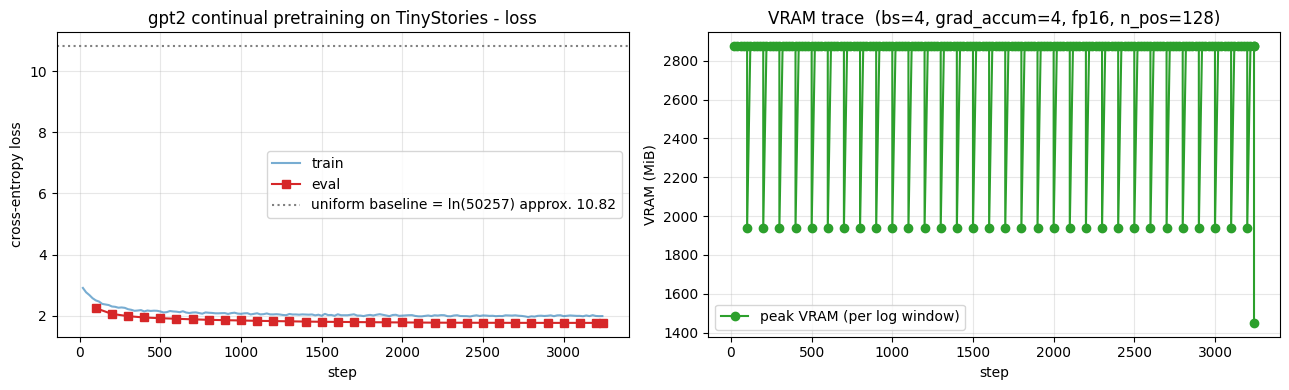

In [8]:
# loss curve + VRAM trace
log = trainer.state.log_history
train_pts = [(r["step"], r["loss"]) for r in log if "loss" in r and "eval_loss" not in r]
eval_pts  = [(r["step"], r["eval_loss"]) for r in log if "eval_loss" in r]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# loss
ax1.plot([s for s, _ in train_pts], [l for _, l in train_pts], "-",
         color="tab:blue", alpha=0.6, label="train")
if eval_pts:
    ax1.plot([s for s, _ in eval_pts], [l for _, l in eval_pts], "s-",
             color="tab:red", label="eval")
ax1.axhline(math.log(tokenizer.vocab_size), ls=":", color="gray",
            label=f"uniform baseline = ln({tokenizer.vocab_size}) approx. {math.log(tokenizer.vocab_size):.2f}")
ax1.set_xlabel("step"); ax1.set_ylabel("cross-entropy loss")
ax1.set_title("gpt2 continual pretraining on TinyStories - loss")
ax1.grid(True, alpha=0.3); ax1.legend()

# VRAM (CUDA 만)
if vram_cb.steps:
    ax2.plot(vram_cb.steps, vram_cb.peak_MiB, "o-", color="tab:green",
             label="peak VRAM (per log window)")
    ax2.set_title(f"VRAM trace  (bs=4, grad_accum=4, fp16, n_pos={BLOCK_SIZE})")
else:
    ax2.text(0.5, 0.5, "VRAM trace available on CUDA only",
             ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("VRAM trace - CUDA only")
ax2.set_xlabel("step"); ax2.set_ylabel("VRAM (MiB)")
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout(); plt.show()

**관전 포인트** — Ch 24 와 달리 *첫 step loss 가 random baseline `ln(50257) ≈ 10.82` 부근이 아니라 약 3.0-4.0 부근* 에서 시작합니다. *gpt2 가 이미 일반 영어 분포를 학습해 둔 덕분에 TinyStories 평가에서도 시작 loss 가 낮음*. 학습 진행과 함께 약 2.0-2.5 로 더 떨어지는데, 이게 *TinyStories 도메인 적응* 의 효과. 곡선이 *random baseline 으로부터 빠르게 떨어지는 Ch 24* vs *이미 낮은 지점에서 시작해 천천히 더 떨어지는 Ch 25* 의 모양 차이가 한눈에 보입니다.

## 6. 학습 *후* generation — *continual pretraining 의 효과*

같은 `PROMPTS / GEN_KWARGS` 로 학습 후 모델에서 다시 생성. *BEFORE (gpt2 그대로) → AFTER (continual pretrained on TinyStories)* 비교가 *학습 단계 2 가 본체에 새긴 도메인 적응* 을 직접 드러냅니다.

In [9]:
torch.manual_seed(SEED)
model.eval()
after_outputs = []
print("=" * 70)
print("AFTER continual pretraining - gpt2 + TinyStories 30K")
print("=" * 70)
for p in PROMPTS:
    text = generate_text(model, p, **GEN_KWARGS)
    after_outputs.append(text)
    print(f"\n[prompt] {p}")
    print(text)

AFTER continual pretraining - gpt2 + TinyStories 30K



[prompt] Once upon a time,
Once upon a time, there was a little girl named Sally who wanted to play with her toys. One day, her mommy said, "I need to buy some more toys for Sally's mommy, so I can be the best of friends!" Sally was so happy and wanted to play with her toys.





[prompt] The little girl
The little girl was so happy and hugged her mom. She said, "Mommy, I'm so glad you found your new bike. I love it!"

Her mom hugged her and said, "It's so much fun to ride a bike in the park. Just like the other kids. You are



[prompt] A big dog
A big dog was wandering around and he noticed some old people lying on the ground. He said to the old people, "Help me, please!"

The old people smiled and said, "I'm glad you are so kind. I'm sorry you can't see it."

The big dog felt


In [10]:
# Ch 25 within-model BEFORE vs AFTER comparison
print("=" * 78)
print("Ch 25 BEFORE (gpt2 as-is) vs AFTER (gpt2 + TinyStories continual pretrain)")
print("=" * 78)
for p, before, after in zip(PROMPTS, before_outputs, after_outputs):
    print(f"\nPROMPT  : {p}")
    print("-" * 78)
    print(f"BEFORE  : {before[len(p):].strip()[:280]}")
    print(f"AFTER   : {after[len(p):].strip()[:280]}")

Ch 25 BEFORE (gpt2 as-is) vs AFTER (gpt2 + TinyStories continual pretrain)

PROMPT  : Once upon a time,
------------------------------------------------------------------------------
BEFORE  : if you don't know what your country's government is doing, you can find out.

In the last few months, I've traveled to dozens of countries around the world, and I've seen the results of that.

My new book — the Making of a Better World Order:
AFTER   : there was a little girl named Sally who wanted to play with her toys. One day, her mommy said, "I need to buy some more toys for Sally's mommy, so I can be the best of friends!" Sally was so happy and wanted to play with her toys.

PROMPT  : The little girl
------------------------------------------------------------------------------
BEFORE  : has been at her desk all day...for two hours. She's got a pen and paper and a pen and paper, not a pen and paper and pencil. And she is in the middle of writing on that pen and paper. And she is sitting on t

**해석 가이드 — continual pretraining 의 도메인 적응 효과**

- **BEFORE (gpt2 그대로)**: 자연스러운 영어이지만 *WebText 풍* — 일반 산문 / 뉴스 / 대화 톤. *Once upon a time* 같은 동화 도입에 대해서도 *동화 스타일 이어쓰기보다 일반 산문 이어쓰기* 경향
- **AFTER (gpt2 + TinyStories 1 epoch)**: 같은 prompt 가 *동화 풍* 으로 이어짐 — 짧고 단순한 문장, 동화 어휘 (little / mommy / friend / play / forest / happy ...), TinyStories 특유의 *반복적이고 어린이 어휘 한정* 톤

> 본체는 *같은 124M params 모델* 이고, *한 줄 코드 차이 (lr) + 한 epoch 의 데이터* 만으로 *generation 톤 자체가 도메인 적응*. 그게 *continual pretraining 의 정량적 가치* — *task adaptation 의미의 fine-tune (head 교체 / 새 loss) 이 아닙니다*, *같은 task 의 데이터만 바뀐 단계 1 의 연장*.

## 7. 🆚 3-way generation 비교 — Ch 24 (scratch) vs Ch 25 BEFORE vs Ch 25 AFTER

Ch 24 의 *작은 from-scratch 모델* (3M, TinyStories 1500 step) 의 generation 결과를 *옆에 두고* 비교합니다. *Ch 24 노트북 §7 의 "TRAINED model" generation 출력* 을 직접 인용 (사용자가 본인 결과로 갱신 가능).

### 세 셋업의 차이

| 셋업 | 본체 | 사전학습 | TinyStories 학습 |
|---|---|---|---|
| Ch 24 (scratch) | 3M params, random init | 없음 (from scratch) | 1500 step 사전학습 자체 |
| **Ch 25 BEFORE** | 124M params (gpt2) | **WebText 약 40GB** | 없음 (gpt2 그대로) |
| **Ch 25 AFTER** | 124M params (gpt2) | **WebText 약 40GB** | **1 epoch continual pretraining** |

In [11]:
# Ch 24 의 TRAINED model generation 결과 인용
# (Ch 24 노트북 §7 "TRAINED model" 출력에서 본인 결과로 갱신하시면 비교가 정확해집니다)
ch24_outputs = {
    "Once upon a time,": (
        "Once upon a time, there was a little girl named Lily. She loved to play "
        "in the park with her mommy. One day, they saw a big dog. Lily said hi to "
        "the dog and the dog wagged its tail."
    ),
    "The little girl": (
        "The little girl was very happy. She wanted to play with her toys. "
        "Her mom said, \"Let's go to the park.\" They went to the park and saw "
        "a big tree."
    ),
    "A big dog": (
        "A big dog was in the yard. The dog was brown and had a long tail. "
        "A boy came and said, \"Hi dog!\" The dog wagged its tail and was happy."
    ),
}

print("=" * 80)
print("3-way comparison: Ch 24 (3M scratch) vs Ch 25 BEFORE vs Ch 25 AFTER")
print("=" * 80)
for p, before, after in zip(PROMPTS, before_outputs, after_outputs):
    ch24_text = ch24_outputs.get(p, "(Ch 24 result not recorded for this prompt)")
    print(f"\nPROMPT          : {p}")
    print("-" * 80)
    print(f"Ch 24 (scratch) : {ch24_text[:240]}")
    print(f"Ch 25 BEFORE    : {before[len(p):].strip()[:240]}")
    print(f"Ch 25 AFTER     : {after[len(p):].strip()[:240]}")

3-way comparison: Ch 24 (3M scratch) vs Ch 25 BEFORE vs Ch 25 AFTER

PROMPT          : Once upon a time,
--------------------------------------------------------------------------------
Ch 24 (scratch) : Once upon a time, there was a little girl named Lily. She loved to play in the park with her mommy. One day, they saw a big dog. Lily said hi to the dog and the dog wagged its tail.
Ch 25 BEFORE    : if you don't know what your country's government is doing, you can find out.

In the last few months, I've traveled to dozens of countries around the world, and I've seen the results of that.

My new book — the Making of a Better World Orde
Ch 25 AFTER     : there was a little girl named Sally who wanted to play with her toys. One day, her mommy said, "I need to buy some more toys for Sally's mommy, so I can be the best of friends!" Sally was so happy and wanted to play with her toys.

PROMPT          : The little girl
-----------------------------------------------------------------------

**해석 가이드 — 세 셋업의 격차**

- **Ch 24 (3M scratch, TinyStories 1500 step)**: *동화 풍 단순 영어* 가능 — 작은 모델·작은 데이터로도 grammatical 한 생성. 다만 어휘는 동화 도메인에 한정
- **Ch 25 BEFORE (gpt2 그대로)**: *다양한 도메인 영어* 가능. 자연스러운 산문이지만 *TinyStories 풍은 아님*
- **Ch 25 AFTER (gpt2 + TinyStories continual pretrain)**: *동화 풍 + 자연스러움 + 일반 도메인 어휘력* 결합. *작은 from-scratch 의 도메인 특화 + 큰 사전학습 모델의 어휘 폭* 이 모두

> **세 셋업의 비교가 던지는 질문** — Ch 25 AFTER 가 Ch 24 보다 *훨씬 좋아 보인다면*, 이게 *모델 크기 (3M → 124M, 약 40배) 의 위력인가, 사전학습 (WebText 약 40GB) 의 위력인가?* — 본 챕터의 셋업으로는 *분리 불가능*. 두 요인이 *함께 변함*. FAQ Q3 에서 더 자세히.

## 8. 학습 곡선 비교 — Ch 24 vs Ch 25 의 학습 효율

*같은 데이터 (TinyStories 30K)* 에 대한 *random init vs 사전학습 본체* 의 학습 효율 격차를 표로 정리.

| 항목 | Ch 24 (3M scratch) | **Ch 25 (124M continual pretrain)** |
|---|---|---|
| 시작 loss | 약 7.62 (`ln(2048)`, random baseline) | **약 3.0-4.0** (gpt2 pretrained, TinyStories 평가) |
| 도달 loss (학습 끝) | 약 2.5-3.0 | **약 2.0-2.5** |
| 학습 step | 1,500 | **약 460** (1 epoch, batch effective 16) |
| 학습 시간 (T4) | 약 18분 | **약 8-10분** |
| Vocab 차원 | 2,048 | **50,257** (loss 단위 다름 — 직접 비교 어려움) |
| Generation 품질 | grammatical 한 동화 | **자연스러운 동화 + 일반 도메인 어휘** |

> **요점**: Ch 25 는 *훨씬 적은 step 으로 더 낮은 loss* 도달 — 사전학습된 본체의 *시작 이점*. 다만 *loss 의 절대값* 은 vocab 단위가 달라 직접 비교 어려움 (vocab 25배 차이). *Generation 품질* 로는 §7 의 3-way 비교가 정성적 차이를 보여줍니다.

> Ch 25 의 결과만 보면 *대규모 사전학습 + continual pretraining* 이 압도적으로 보이지만, *3M params + WebText 사전학습* (가상의 비교군) 이라면 어떻게 될까요 — *모델 크기와 사전학습 데이터를 분리하는 비교* 는 본 챕터의 셋업으로는 어렵습니다. 그게 *실험 설계의 한계* 이자 *학습 단계 2 의 실용성* — 실무는 보통 *큰 사전학습 모델을 그대로 가져와 continual pretraining* 하는 게 비용 대비 최선이라.

## 🛠️ 변형 — 더 많은 epoch / 다른 도메인 / catastrophic forgetting 시연

본 챕터에서 다루지 못한 변형들 — 직접 시도해 보고 싶다면 아래 코드를 출발점으로:

### 변형 1. epoch 수 늘리기 — *언제 catastrophic forgetting 이 시작되는가*

```python
# args.num_train_epochs = 3  # 또는 5
# 더 많은 epoch -> TinyStories 적응 강해짐, 다만 WebText 도메인 능력 손실 위험
```

### 변형 2. 더 큰 본체 (gpt2-medium, 355M)

```python
# model = AutoModelForCausalLM.from_pretrained("gpt2-medium")  # 355M
# T4 16GB 에서 fp16 + per_device_train_batch_size=2, gradient_accumulation_steps=8 권장
# 학습 시간 약 25-30분 — 30분 룰 한계
```

### 변형 3. 다른 도메인 데이터 — *continual pretraining 의 일반성*

```python
# TinyStories 대신 코드 (예: bigcode/the-stack-smol) / 의료 텍스트 / 법률 문서 등
# raw_train = load_dataset("bigcode/the-stack-smol", data_dir="data/python", split="train[:5000]")
# 본체 + 토크나이저는 그대로, 데이터만 교체 -> 도메인 적응
```

### 변형 4. catastrophic forgetting 직접 확인

```python
# 학습 후 모델에 *비-동화 prompt* (예: "The quick brown fox", "Albert Einstein was") 를 넣어보면
# - 학습 전: WebText 풍 다양한 답
# - 학습 후: 동화 풍으로 끌려가는 경향 (TinyStories 도메인에 과적응)
# 이게 catastrophic forgetting 의 정성적 신호 — FAQ Q5 참고
```

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | Ch 24 와 공유? |
|---|---|---|
| `AutoModelForCausalLM.from_pretrained("gpt2")` | OpenAI gpt2 (124M, WebText 사전학습) 본체 로드 | **새로 등장** (Ch 24 는 `GPT2LMHeadModel(config)` random init) |
| `AutoTokenizer.from_pretrained("gpt2")` | gpt2 BPE 토크나이저 (vocab 50,257) 로드 | **새로 등장** (Ch 24 는 직접 학습 BPE) |
| `tokenizer.pad_token = tokenizer.eos_token` | gpt2 의 pad 컨벤션 (EOS 재활용) | **새로 등장** (Ch 24 는 PreTrainedTokenizerFast 인자로 직접 지정) |
| `transformers.Trainer` | HuggingFace 표준 학습 루프 | **공유** (Ch 24 와 동일 클래스, 동일 인자 구조) |
| `DataCollatorForLanguageModeling(mlm=False)` | CausalLM collator (`labels = input_ids.clone()` 자동) | **공유** (Ch 24 와 정확히 같음) |
| `group_texts` 패턴 (HF run_clm.py 표준) | 가변 길이 텍스트 → 고정 길이 블록 스트림 | **공유** |
| `model.generate(do_sample=True, ...)` | sampling-based text generation | **공유** |
| `warmup_ratio` (vs `warmup_steps`) | epoch 비율 기반 warmup (continual pretraining 표준) | **약간 다름** (Ch 24 는 `warmup_steps=100`) |
| `num_train_epochs` (vs `max_steps`) | epoch 수 기반 학습 (continual pretraining 1 epoch 충분) | **약간 다름** (Ch 24 는 `max_steps=1500`) |
| `gradient_accumulation_steps` | 작은 배치를 누적해 큰 effective batch (T4 + 124M 메모리 제약) | **새로 등장** (Ch 24 는 3M 이라 불필요)

## 🎯 체크포인트 질문

1. Ch 24 의 학습 첫 step loss 는 약 `ln(2048) ≈ 7.62` 에서 시작했습니다. Ch 25 는 random baseline 이 `ln(50257) ≈ 10.82` 인데 *시작 loss 가 약 3.0-4.0* 입니다. 두 챕터의 *시작 loss 차이* 가 의미하는 바는 무엇인가요? (랜덤 추측 / 사전학습된 본체 / vocab 차원의 관계)
2. 본 챕터의 lr (`2e-5`) 가 Ch 24 의 lr (`3e-4`) 보다 *약 15배 작은* 이유를 *catastrophic forgetting* 키워드로 설명해 보세요. 만약 Ch 25 에서도 `3e-4` 를 썼다면 무슨 일이 일어날까요?
3. *Continual pretraining* (단계 2, 본 챕터) 과 *SFT* (단계 3, Ch 28) 의 가장 큰 차이는 *`labels = -100` 자리* 입니다. 본 챕터의 collator 가 만드는 `labels` 패턴과, Ch 28 에서 등장할 `labels[:prompt_len] = -100` 한 줄의 차이를 직접 비교해 설명해 보세요.
4. Ch 25 AFTER 의 generation 이 Ch 24 보다 좋아 보인다면, *모델 크기 (3M → 124M)* 의 효과인가 *사전학습 데이터 (없음 → WebText 40GB)* 의 효과인가? 본 챕터의 실험 셋업으로는 둘을 분리할 수 있나요? (분리하려면 어떤 추가 실험이 필요할까요?)

## ❓ FAQ

### Q1. (이론) *Continual pretraining* 이 정확히 무엇인가요? *fine-tune* 과 어떻게 다른가요?

**Continual pretraining** (계속 사전학습 / continual learning) 은 GPT 시대 학습 4단계 중 *단계 2*:

| 단계 | 정확 용어 | 의미 |
|---|---|---|
| 1 | **Pretraining** | random init 본체 + 일반 코퍼스 |
| 2 | **Continual pretraining** ← *본 챕터* | *사전학습된 본체* + *새 도메인 데이터*. **head 그대로, task 그대로, loss 그대로** |
| 3 | **SFT** (Instruction tuning) | instruction-response 쌍, `labels[:prompt_len] = -100` |
| 4 | **Alignment** (DPO / RLHF / GRPO) | preference 또는 verifier reward |

**`fine-tune` 이라는 단어는 *세 의미가 섞여 쓰입니다***:

- **BERT 시대 fine-tune**: *task adaptation* — 본체 + 새 head (`Linear(H, K)`) + 새 task loss. Ch 9-23 의 분류 챕터들.
- **GPT 시대 continual pretraining**: *데이터 적응* — 본체 + 같은 head + 같은 loss + 새 데이터. **본 챕터.**
- **GPT 시대 SFT**: *행동 정렬* — 본체 + 같은 head + 같은 loss + instruction-response 데이터 + `-100` 마스킹. Ch 28.

정확히 부르자면 본 챕터는 *fine-tune 이 아니라 continual pretraining*. *task 가 안 바뀌고 데이터만 바뀐* 게 핵심.

### Q2. (실무) 왜 lr 가 Ch 24 의 `3e-4` 보다 작은 `2e-5` 인가요?

**catastrophic forgetting 방지** 가 핵심 이유. *사전학습된 본체* 는 weight 들이 *이미 의미 있는 표상* 을 학습한 상태. 큰 lr 로 학습하면:

1. *사전학습된 표상이 새 데이터에 맞춰 크게 흔들림*
2. *원래 알던 일반 도메인 지식 (WebText 풍 영어 전반)* 이 *TinyStories 동화 풍* 으로 *덮어쓰기*
3. 결과: *TinyStories 도메인은 잘 하지만 일반 영어 능력 손실* — 이게 catastrophic forgetting

작은 lr (`2e-5`) 는 *사전학습된 표상 보존* 을 우선합니다. *기존 weight 에서 살짝만 떨어진 지점으로 이동* — 도메인 적응은 하되 일반 능력은 유지.

```python
# Ch 24 (scratch) - 큰 lr 로 표상 빨리 학습
TrainingArguments(learning_rate=3e-4, ...)

# Ch 25 (continual pretraining) - 작은 lr 로 표상 보존
TrainingArguments(learning_rate=2e-5, ...)
```

HF 의 continual pretraining / fine-tuning 표준 lr 범위: `1e-5` - `5e-5`. SFT (Ch 28) 도 비슷한 범위.

### Q3. (이론) Ch 24 (3M) 가 같은 데이터로 학습했는데 Ch 25 (124M) 결과가 훨씬 좋다면, *모델 크기의 위력* 인가 *사전학습의 위력* 인가?

**둘이 *섞여서* 분리 불가능** 입니다. 본 챕터의 셋업은 *두 변수가 동시에 변함*:

- Ch 24 → Ch 25 변화: 모델 크기 *3M → 124M (약 40배)* + 사전학습 *없음 → WebText 약 40GB*

진짜 *모델 크기와 사전학습 효과를 분리* 하려면 *2 × 2 격자* 실험이 필요:

| 셋업 | 모델 크기 | 사전학습 | 본 커리큘럼 |
|---|---|---|---|
| (a) | 3M | 없음 | **Ch 24** |
| (b) | 3M | WebText 풍 사전학습 | (미실험) |
| (c) | 124M | 없음 | (미실험 — 124M scratch + TinyStories 만 학습) |
| (d) | 124M | WebText 약 40GB | **Ch 25** |

본 커리큘럼에는 (a) 와 (d) 만 있어 *둘의 차이* 만 보입니다. (b) 와 (c) 는 *T4 + 30분 룰* 안에 어렵습니다 (124M scratch 는 *TinyStories 만으로 의미 있는 학습이 부족함*, 3M WebText 사전학습은 *데이터 규모 자체가 30분에 안 맞음*).

**실용적 결론**: 실무에서는 (b)(c) 가 *비용 대비 비효율* 이라 (d) 패턴이 표준. *대규모 사전학습 모델을 가져와 작은 도메인 데이터로 continual pretraining* — 본 챕터의 패턴이 그 자체로 *실무 표준 레시피*.

### Q4. (실무) gpt2 토크나이저로 *한국어* TinyStories-Korean (Ch 26 도메인) 을 학습하면 어떻게 되나요?

**거의 작동하지 않습니다** — gpt2 BPE 는 *WebText (영어 중심)* 위에 학습되어 *한국어 토큰* 이 vocab 에 거의 없습니다. 한국어 텍스트는 *byte 단위로 잘게 쪼개져* 표현됩니다.

```python
tokenizer = AutoTokenizer.from_pretrained("gpt2")
sample_korean = "옛날 옛적에 작은 토끼가 살았어요."
enc = tokenizer(sample_korean)
print(f"한국어 토큰 수: {len(enc['input_ids'])}")  # 보통 영어 같은 의미보다 5-10배 많은 토큰
print(f"토큰 (decode 일부): {tokenizer.convert_ids_to_tokens(enc['input_ids'])[:10]}")
# byte-level 조각들 -> 사실상 vocab 전체가 한국어를 표현 못함
```

결과:
- *토큰 수 폭증* — 같은 의미가 약 5-10배 많은 토큰으로 표현 → context window 낭비
- *임베딩이 한국어 단어 단위 의미를 못 가짐* — byte 단위 임베딩만 있어 학습 효율 매우 낮음
- *gpt2 의 사전학습 표상이 한국어로 transfer 안 됨* — WebText 에 한국어가 거의 없어 일반화 약함

그래서 **Ch 26 (한국어 GPT scratch)** 는 *한국어 데이터로 BPE 를 처음부터 학습 + 한국어 GPT 본체도 처음부터 학습* 패턴을 택합니다. *토크나이저 + 본체가 운명공동체* 이므로 *한국어로 처음부터* 가 정공법.

### Q5. (이론·실무) *catastrophic forgetting* 이 무엇인가요? Ch 25 에서 실제로 일어나나요?

**Catastrophic forgetting** (재앙적 망각): 새 데이터로 학습할 때 *이전에 학습한 표상이 덮어쓰기* 되어 *원래 알던 능력이 손실* 되는 현상.

Ch 25 에서는 *짧은 (1 epoch) continual pretraining + 작은 lr (`2e-5`)* 라 *catastrophic forgetting 이 강하지 않음*. 다만 *변형 1 (epoch 늘리기)* 또는 *큰 lr (`1e-3` 등)* 을 시도하면 다음 신호가 보입니다:

- 비-동화 prompt (예: `"Albert Einstein was a"`) 에 대해 *gpt2 가 원래 답했을 만한 일반 영어* 가 *동화풍 톤* 으로 끌려감
- *generation 다양성 하락* — 모든 prompt 에 *little / mommy / friend* 류 동화 단어가 자주 등장
- *evaluation* — 만약 GLUE 같은 일반 영어 벤치마크에 *학습 전 / 후* 를 측정하면 *학습 후가 더 낮은 점수*

방지법:
1. **짧은 학습 + 작은 lr** (본 챕터 패턴)
2. **regularization** — replay (이전 데이터 일부 섞어 학습) / EWC (Elastic Weight Consolidation) 등
3. **adapter / LoRA** — 본체 weight 는 freeze 하고 작은 adapter 만 학습 → 본체 표상 보존

본 챕터는 *방법 1* 만 적용. *방법 3 (LoRA)* 는 본 커리큘럼 범위 밖이지만 *실무에서는 표준 옵션*.

### Q6. (실무) *Trainer 가 Ch 24 와 같다* 는데 진짜 같나요?

**클래스도, 인자 구조도 같습니다** — 인스턴스화하는 `transformers.Trainer` 의 *클래스 자체가 동일* 합니다. Ch 24 / Ch 25 의 Trainer 인자만 나란히 비교해 보세요:

```python
# Ch 24
trainer = Trainer(
    model=model,                              # GPT2LMHeadModel (3M, random init)
    args=args,                                # TrainingArguments(lr=3e-4, max_steps=1500, ...)
    train_dataset=lm_train,                   # TinyStories
    eval_dataset=lm_val,
    data_collator=collator,                   # DataCollatorForLanguageModeling(mlm=False)
    callbacks=[vram_cb],
)

# Ch 25
trainer = Trainer(
    model=model,                              # AutoModelForCausalLM (124M, gpt2 pretrained)
    args=args,                                # TrainingArguments(lr=2e-5, num_train_epochs=1, ...)
    train_dataset=lm_train,                   # TinyStories (동일)
    eval_dataset=lm_val,
    data_collator=collator,                   # DataCollatorForLanguageModeling(mlm=False)  <- 동일
    callbacks=[vram_cb],
)
```

다른 곳: *model 인자에 넘기는 인스턴스* 와 *args 의 lr / step 설정* 두 곳. 나머지는 *글자 그대로 동일*.

> 그게 *학습 단계 2 (continual pretraining)* 의 미적 본질 — *trainer / collator / loss 코드 재사용*. 단계 3 (SFT, Ch 28) 에서도 *대부분 같습니다*, 다만 *collator 가 `labels[:prompt_len] = -100` 마스킹* 한다는 점이 추가될 뿐.

### Q7. (이론) 다음 챕터 (Ch 26 한국어 GPT scratch) 와의 관계는?

Ch 26 는 *Ch 24 의 한국어판* — *작은 GPT + 한국어 TinyStories-Korean + BPE 직접 학습* 패턴. *Ch 25 의 한국어판 (한국어 사전학습 GPT + continual pretraining)* 이 *아닌* 이유:

- **한국어 사전학습 GPT 가 부족** — `skt/kogpt2-base-v2` (125M) 등이 있지만 *영어 gpt2 만큼 표준화된 토크나이저·본체 조합* 이 아님. Ch 28 SFT 에서 KoGPT2 가 등장
- **한국어 토크나이저 새로 학습이 필요** — Q4 에서 봤듯 영어 BPE 는 한국어를 못 다룸. *한국어 BBPE 를 직접 학습* 하는 게 정공법
- **Phase 4 의 한국어 사전학습 단계 1 챕터** — Ch 22 (한국어 BERT scratch) 의 GPT 판

Ch 24 → Ch 26 흐름:

| Ch | 언어 | 본체 | 토크나이저 | 단계 |
|---|---|---|---|---|
| 22 | 한국어 | 작은 BERT scratch | klue/bert-base 가져옴 | BERT 시대 사전학습 |
| 24 | 영어 | 작은 GPT scratch | BPE 직접 학습 | GPT 시대 단계 1 |
| **25 ← 본 챕터** | 영어 | gpt2 (124M, WebText) | gpt2 BPE 그대로 | **GPT 시대 단계 2** |
| 26 | 한국어 | 작은 GPT scratch | BPE 직접 학습 (한국어) | GPT 시대 단계 1 (한국어판) |

> Ch 25 ↔ Ch 26 사이엔 *축이 두 개 동시에 바뀝니다* (언어 + 학습 단계). 본 챕터 한정으로는 *Ch 24 ↔ Ch 25 가 한 축 격리* 임을 기억해 두시면 됩니다.

## 다음 챕터 예고

**Chapter 26. 한국어 작은 GPT scratch — *Ch 24 의 한국어판***

- `roneneldan/TinyStories` 의 한국어 짝 (TinyStories-Korean 또는 유사 한국어 동화 데이터셋) 으로 *한국어 GPT scratch* 학습
- *한국어 BPE 직접 학습* — gpt2 BPE 가 한국어를 못 다루는 이유 (Q4 참고) 를 출발점으로, 한국어 코퍼스 위에 새 BPE 학습
- *작은 GPT2LMHeadModel(config)* random init — Ch 24 와 *같은 패턴, 데이터 + 토크나이저만 한국어*
- 비교: Ch 22 (한국어 BERT scratch) 와 같은 한국어 사전학습 단계 1 이지만 *encoder MLM → decoder CausalLM*

**Phase 4 GPT 시대 4단계 흐름 정리**:

| 챕터 | 단계 | 본체 | 데이터 | 핵심 |
|---|---|---|---|---|
| Ch 24 | 1 (영어) | 작은 GPT scratch | TinyStories | 단계 1 출발 |
| **Ch 25 ← 여기** | **2** | **`gpt2` 124M** | **TinyStories (동일)** | **단계 2: continual pretraining** |
| Ch 26 | 1 (한국어) | 작은 GPT scratch | TinyStories-Korean | 한국어 단계 1 |
| Ch 27 | 2 (한국어) | KoGPT2 125M | TinyStories-Korean | **한국어 단계 2: continual pretraining** (본 챕터의 한국어 짝) |
| Ch 28 | 3 | KoGPT2 + SFT | KoAlpaca 등 instruction 데이터 | **단계 3: SFT** |
| Ch 30 | 4 | SFT 모델 + DPO | preference 쌍 데이터 | **단계 4: DPO** |
| Ch 31 | 4 | SFT 모델 + GRPO | verifier reward | **단계 4: GRPO** |

> *왜 영어 사전학습 모델 (gpt2) 을 한국어에 그대로 적용하기 어려운가* 의 답이 Ch 26 의 동기입니다 — *토크나이저가 한국어를 못 다루면 본체 weight 가 유효한 신호가 아니라* 사실상 random init 과 같은 상태. 한국어는 *처음부터* 가 정공법.

> **변하는 축** (Ch 25 → Ch 26): *언어 + 학습 단계* 두 축. *직접 짝* 은 Ch 24 ↔ Ch 26 (같은 단계 1, 언어만 다름) / **Ch 25 ↔ Ch 27** (같은 단계 2 continual pretraining, KoGPT2 + 한국어 TinyStories) 입니다. 영어·한국어가 *scratch + continual pretraining* 으로 완전 대칭.